# 04 - LSTM Inflation Nowcasting

Train a deterministic stacked LSTM baseline for monthly inflation nowcasting using processed outputs from notebook 02.

## Why try an LSTM here?
Inflation is path-dependent, so sequence models can capture multi-month interactions between labor, policy, liquidity, energy, and sentiment signals.

Main risks:
- monthly macro datasets are small (easy to overfit)
- regime shifts can break older learned patterns
- interpretability is weaker than classical baselines

So we keep this notebook strict: fixed seeds, chronological splits, and early stopping.

In [1]:
from pathlib import Path
import sys
import os
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib

# Determinism: set env flags before TensorFlow import.
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.project_utils import ensure_project_dirs, seed_everything

seed_everything(42)

import tensorflow as tf

tf.keras.utils.set_random_seed(42)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

paths = ensure_project_dirs()
lstm_dir = paths["results"] / "lstm"
lstm_dir.mkdir(parents=True, exist_ok=True)

MODEL_PATH = paths["models"] / "lstm_model.keras"
SCALER_PATH = paths["models"] / "lstm_feature_scaler.joblib"
METRICS_PATH = lstm_dir / "metrics.json"
LEARNING_CURVE_PATH = lstm_dir / "learning_curves.png"
PREDS_PLOT_PATH = lstm_dir / "preds_vs_actuals.png"

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_columns = 200

print("Repo root:", ROOT)
print("TensorFlow version:", tf.__version__)
print("Results dir:", lstm_dir)

Repo root: C:\Users\jijos\Desktop\261-Project
TensorFlow version: 2.20.0
Results dir: C:\Users\jijos\Desktop\261-Project\results\lstm


## Config
All training settings live in one config dictionary so experiments stay easy to track and reproduce.

In [2]:
CONFIG = {
    "seed": 42,
    "lag_length": 24,
    "target_mode": "delta",  # options: "level", "delta"
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "epochs": 220,
    "batch_size": 16,
    "learning_rate": 1e-3,
    "dropout": 0.20,
    "lstm_units_1": 64,
    "lstm_units_2": 32,
    "dense_units": 16,
    "early_stopping_patience": 25,
    "early_stopping_min_delta": 1e-4,
    "reduce_lr_patience": 10,
    "reduce_lr_factor": 0.5,
    "min_learning_rate": 1e-5,
    "modeling_table_path": None,
    "feature_set_preference": "full",
    "mase_m": 1,
}

if CONFIG["lag_length"] <= 0:
    raise ValueError("lag_length must be positive")
if CONFIG["target_mode"] not in {"level", "delta"}:
    raise ValueError("target_mode must be 'level' or 'delta'")
if not (0.0 < CONFIG["train_ratio"] < 1.0 and 0.0 < CONFIG["val_ratio"] < 1.0):
    raise ValueError("train_ratio and val_ratio must be in (0,1)")
if CONFIG["train_ratio"] + CONFIG["val_ratio"] >= 1.0:
    raise ValueError("train_ratio + val_ratio must be < 1.0")

print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "lag_length": 24,
  "target_mode": "delta",
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "epochs": 220,
  "batch_size": 16,
  "learning_rate": 0.001,
  "dropout": 0.2,
  "lstm_units_1": 64,
  "lstm_units_2": 32,
  "dense_units": 16,
  "early_stopping_patience": 25,
  "early_stopping_min_delta": 0.0001,
  "reduce_lr_patience": 10,
  "reduce_lr_factor": 0.5,
  "min_learning_rate": 1e-05,
  "modeling_table_path": null,
  "feature_set_preference": "full",
  "mase_m": 1
}


## Load processed data and split metadata
Notebook 02 generates the modeling table and split metadata reused here.
We keep the same split boundaries and rebuild sequence windows from those boundaries.

In [3]:
split_meta_path = paths["processed_data"] / "split_metadata.json"
if not split_meta_path.exists():
    raise FileNotFoundError("Missing split metadata. Run notebook 02_feature_engineering_and_splits.ipynb first.")

split_meta = json.loads(split_meta_path.read_text(encoding="utf-8"))

if CONFIG["modeling_table_path"]:
    model_table_path = Path(CONFIG["modeling_table_path"])
else:
    candidate_paths = []
    meta_feature_set = split_meta.get("feature_set")
    if meta_feature_set:
        candidate_paths.append(paths["processed_data"] / f"modeling_table_{meta_feature_set}.csv")
    candidate_paths.append(paths["processed_data"] / f"modeling_table_{CONFIG['feature_set_preference']}.csv")
    candidate_paths.extend(sorted(paths["processed_data"].glob("modeling_table_*.csv")))

    model_table_path = None
    for p in candidate_paths:
        if p.exists():
            model_table_path = p
            break

    if model_table_path is None:
        raise FileNotFoundError("No modeling_table_*.csv found. Run notebook 02 first.")

model_df = pd.read_csv(model_table_path, index_col=0, parse_dates=True).sort_index()

TARGET_NAME = split_meta.get("target_name")
if TARGET_NAME is None:
    raise KeyError("target_name is missing from split_metadata.json")
if TARGET_NAME not in model_df.columns:
    raise KeyError(f"Target column {TARGET_NAME!r} is missing from {model_table_path}")

selected_features = split_meta.get("selected_features")
if selected_features:
    selected_features = [f for f in selected_features if f in model_df.columns and f != TARGET_NAME]
else:
    selected_features = [c for c in model_df.columns if c != TARGET_NAME]

if len(selected_features) == 0:
    raise ValueError("No usable feature columns were found in the modeling table.")

train_end = int(split_meta["boundaries"]["train_end_idx"])
val_end = int(split_meta["boundaries"]["val_end_idx"])

if not (0 < train_end < val_end < len(model_df)):
    raise ValueError("Invalid chronological boundaries in split metadata.")
if CONFIG["lag_length"] >= train_end:
    raise ValueError(
        f"lag_length={CONFIG['lag_length']} is too large for train split size {train_end}."
    )

X_df = model_df[selected_features].copy()
y_sr = model_df[TARGET_NAME].copy()

print("Modeling table:", model_table_path)
print("Rows:", len(model_df), "| Features:", len(selected_features))
print("Target:", TARGET_NAME)
print("Split boundaries (row indices):", {"train_end": train_end, "val_end": val_end})
print("Date range:", model_df.index.min().date(), "to", model_df.index.max().date())

Modeling table: C:\Users\jijos\Desktop\261-Project\data\processed\modeling_table_full.csv
Rows: 395 | Features: 22
Target: target_yoy_t_plus_1
Split boundaries (row indices): {'train_end': 347, 'val_end': 371}
Date range: 1993-01-01 to 2026-01-01


## Sequence builder and metrics

In [4]:
def compute_split_bounds(n_rows: int, train_ratio: float = 0.70, val_ratio: float = 0.15) -> tuple[int, int]:
    train_end_local = int(n_rows * train_ratio)
    val_end_local = int(n_rows * (train_ratio + val_ratio))
    return train_end_local, val_end_local


def make_sequences(X_2d: np.ndarray, y_1d: np.ndarray, idx: pd.Index, n_lags: int):
    X_out, y_out, idx_out = [], [], []
    for i in range(n_lags, len(X_2d)):
        X_out.append(X_2d[i - n_lags : i, :])
        y_out.append(y_1d[i])
        idx_out.append(idx[i])
    return np.asarray(X_out, dtype=np.float32), np.asarray(y_out, dtype=np.float32), pd.Index(idx_out)


def build_sequence_splits(X_df: pd.DataFrame, y_sr: pd.Series, n_lags: int, train_end: int, val_end: int):
    X_vals = X_df.values.astype(np.float32)
    y_vals = y_sr.values.astype(np.float32)
    idx = X_df.index

    X_train_rows = X_df.iloc[:train_end]
    X_val_rows = X_df.iloc[train_end:val_end]
    X_test_rows = X_df.iloc[val_end:]

    y_train_rows = y_sr.iloc[:train_end]
    y_val_rows = y_sr.iloc[train_end:val_end]
    y_test_rows = y_sr.iloc[val_end:]

    X_train_seq, y_train_seq, idx_train_seq = make_sequences(
        X_vals[:train_end], y_vals[:train_end], idx[:train_end], n_lags
    )

    val_ctx_start = max(0, train_end - n_lags)
    X_val_block = X_vals[val_ctx_start:val_end]
    y_val_block = y_vals[val_ctx_start:val_end]
    idx_val_block = idx[val_ctx_start:val_end]

    X_val_all, y_val_all, idx_val_all = make_sequences(X_val_block, y_val_block, idx_val_block, n_lags)
    keep_val_from = max(0, train_end - (val_ctx_start + n_lags))

    X_val_seq = X_val_all[keep_val_from:]
    y_val_seq = y_val_all[keep_val_from:]
    idx_val_seq = idx_val_all[keep_val_from:]

    test_ctx_start = max(0, val_end - n_lags)
    X_test_block = X_vals[test_ctx_start:]
    y_test_block = y_vals[test_ctx_start:]
    idx_test_block = idx[test_ctx_start:]

    X_test_all, y_test_all, idx_test_all = make_sequences(X_test_block, y_test_block, idx_test_block, n_lags)
    keep_test_from = max(0, val_end - (test_ctx_start + n_lags))

    X_test_seq = X_test_all[keep_test_from:]
    y_test_seq = y_test_all[keep_test_from:]
    idx_test_seq = idx_test_all[keep_test_from:]

    return {
        "X_train_rows": X_train_rows,
        "X_val_rows": X_val_rows,
        "X_test_rows": X_test_rows,
        "y_train_rows": y_train_rows,
        "y_val_rows": y_val_rows,
        "y_test_rows": y_test_rows,
        "X_train_seq": X_train_seq,
        "y_train_seq": y_train_seq,
        "idx_train_seq": idx_train_seq,
        "X_val_seq": X_val_seq,
        "y_val_seq": y_val_seq,
        "idx_val_seq": idx_val_seq,
        "X_test_seq": X_test_seq,
        "y_test_seq": y_test_seq,
        "idx_test_seq": idx_test_seq,
        "val_ctx_start": val_ctx_start,
        "test_ctx_start": test_ctx_start,
    }


def scale_sequences(X_seq: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    n_samples, n_lags, n_features = X_seq.shape
    flat = X_seq.reshape(-1, n_features)
    scaled = scaler.transform(flat)
    return scaled.reshape(n_samples, n_lags, n_features).astype(np.float32)


def mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))


def smape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))


def mase(y_true, y_pred, y_insample, m: int = 1, eps: float = 1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_insample = np.asarray(y_insample)
    if len(y_insample) <= m:
        return float("nan")
    scale = np.mean(np.abs(y_insample[m:] - y_insample[:-m]))
    return float(np.mean(np.abs(y_true - y_pred)) / (scale + eps))

In [5]:
sequence_data = build_sequence_splits(
    X_df=X_df,
    y_sr=y_sr,
    n_lags=CONFIG["lag_length"],
    train_end=train_end,
    val_end=val_end,
)

# Optional consistency check versus ratio logic (for transparency only).
ratio_train_end, ratio_val_end = compute_split_bounds(
    n_rows=len(model_df),
    train_ratio=CONFIG["train_ratio"],
    val_ratio=CONFIG["val_ratio"],
)
print("Metadata split indices:", train_end, val_end)
print("Ratio-based split indices:", ratio_train_end, ratio_val_end)

if len(sequence_data["X_train_seq"]) == 0 or len(sequence_data["X_val_seq"]) == 0 or len(sequence_data["X_test_seq"]) == 0:
    raise ValueError("At least one sequence split is empty. Reduce lag_length or check data coverage.")

feature_scaler = StandardScaler()
feature_scaler.fit(sequence_data["X_train_rows"].values)

X_train = scale_sequences(sequence_data["X_train_seq"], feature_scaler)
X_val = scale_sequences(sequence_data["X_val_seq"], feature_scaler)
X_test = scale_sequences(sequence_data["X_test_seq"], feature_scaler)

y_train = sequence_data["y_train_seq"].astype(np.float32)
y_val = sequence_data["y_val_seq"].astype(np.float32)
y_test = sequence_data["y_test_seq"].astype(np.float32)

# Use Inflation_prev as anchor for residual/delta modeling.
p_train = X_df.loc[sequence_data["idx_train_seq"], "Inflation_prev"].values.astype(np.float32)
p_val = X_df.loc[sequence_data["idx_val_seq"], "Inflation_prev"].values.astype(np.float32)
p_test = X_df.loc[sequence_data["idx_test_seq"], "Inflation_prev"].values.astype(np.float32)

if CONFIG["target_mode"] == "delta":
    y_train_fit = y_train - p_train
    y_val_fit = y_val - p_val
else:
    y_train_fit = y_train
    y_val_fit = y_val

idx_test = sequence_data["idx_test_seq"]

print("Training shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Feature count:", X_train.shape[2])
print("Lag length used:", CONFIG["lag_length"])
print("Target mode:", CONFIG["target_mode"])
print("Validation context start idx:", sequence_data["val_ctx_start"])
print("Test context start idx:", sequence_data["test_ctx_start"])

Metadata split indices: 347 371
Ratio-based split indices: 276 335
Training shape: (323, 24, 22) (323,)
Validation shape: (24, 24, 22) (24,)
Test shape: (24, 24, 22) (24,)
Feature count: 22
Lag length used: 24
Target mode: delta
Validation context start idx: 323
Test context start idx: 347


## Stacked LSTM baseline
Model shape:
- LSTM layer with sequence output
- second LSTM layer for compression
- dense head
- scalar output for inflation forecast

In [6]:
def build_stacked_lstm(input_shape: tuple[int, int], config: dict) -> tf.keras.Model:
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=input_shape, name="sequence_input"),
            tf.keras.layers.LSTM(
                units=config["lstm_units_1"],
                return_sequences=True,
                dropout=config["dropout"],
                recurrent_dropout=0.0,
                name="lstm_1",
            ),
            tf.keras.layers.LSTM(
                units=config["lstm_units_2"],
                return_sequences=False,
                dropout=config["dropout"],
                recurrent_dropout=0.0,
                name="lstm_2",
            ),
            tf.keras.layers.Dense(config["dense_units"], activation="relu", name="dense_relu"),
            tf.keras.layers.Dropout(config["dropout"], name="dense_dropout"),
            tf.keras.layers.Dense(1, name="inflation_forecast"),
        ],
        name="stacked_lstm_nowcaster",
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=config["learning_rate"])
    model.compile(optimizer=optimizer, loss="mse", metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")])
    return model


tf.keras.backend.clear_session()
model = build_stacked_lstm(input_shape=(X_train.shape[1], X_train.shape[2]), config=CONFIG)
model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=CONFIG["early_stopping_patience"],
    min_delta=CONFIG["early_stopping_min_delta"],
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=CONFIG["reduce_lr_factor"],
    patience=CONFIG["reduce_lr_patience"],
    min_lr=CONFIG["min_learning_rate"],
    verbose=1,
)

history = model.fit(
    X_train,
    y_train_fit,
    validation_data=(X_val, y_val_fit),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    callbacks=[early_stopping, reduce_lr],
    verbose=0,
)

history_df = pd.DataFrame(history.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"

print("Epochs completed:", len(history_df))
print("Final learning rate:", float(tf.keras.backend.get_value(model.optimizer.learning_rate)))
history_df.tail(5)

Model: "stacked_lstm_nowcaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inflation_forecast (Dense)      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,233 (137.63 KB)

 Trainable params: 35,233 (137.63 KB)

 Non-trainable params: 0 (0.00 B)

...


Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


Epoch 38: early stopping


Restoring model weights from the end of the best epoch: 13.


Epochs completed: 38
Final learning rate: 0.0002500000118743628


,loss,mae,val_loss,val_mae,learning_rate
epoch,,,,,
34,0.112061,0.255569,0.223243,0.387132,0.00025
35,0.111139,0.248206,0.230231,0.394741,0.00025
36,0.127866,0.268168,0.253458,0.419627,0.00025
37,0.114403,0.251510,0.267935,0.421944,0.00025
38,0.121164,0.260863,0.222415,0.386084,0.00025


In [7]:
best_epoch = int(history_df["val_loss"].idxmin())
best_val_loss = float(history_df["val_loss"].min())
final_epoch_val_loss = float(history_df["val_loss"].iloc[-1])
restored_val_loss = float(model.evaluate(X_val, y_val_fit, verbose=0)[0])

best_weights_restored = bool(
    early_stopping.restore_best_weights
    and np.isclose(restored_val_loss, best_val_loss, rtol=1e-3, atol=1e-5)
)

print("Best epoch:", best_epoch)
print("Best val_loss from history:", round(best_val_loss, 6))
print("Final-epoch val_loss before restoration check:", round(final_epoch_val_loss, 6))
print("Model val_loss after training (post-restore):", round(restored_val_loss, 6))
print("EarlyStopping restore_best_weights:", early_stopping.restore_best_weights)
print("Best weights restored check:", best_weights_restored)

if not early_stopping.restore_best_weights:
    raise AssertionError("EarlyStopping restore_best_weights should be True.")
if not best_weights_restored:
    raise AssertionError("Best-weight restoration check failed.")

Best epoch: 13
Best val_loss from history: 0.157908
Final-epoch val_loss before restoration check: 0.222415
Model val_loss after training (post-restore): 0.157908
EarlyStopping restore_best_weights: True
Best weights restored check: True


In [8]:
# Refit on train+val before final test evaluation.
# This ensures fitting uses recent regimes while preserving held-out test integrity.

def build_trainval_test_sequences(X_df: pd.DataFrame, y_sr: pd.Series, n_lags: int, val_end_idx: int):
    X_vals = X_df.values.astype(np.float32)
    y_vals = y_sr.values.astype(np.float32)
    idx = X_df.index

    # Train+val sequences
    X_trainval_seq, y_trainval_seq, idx_trainval_seq = make_sequences(
        X_vals[:val_end_idx], y_vals[:val_end_idx], idx[:val_end_idx], n_lags
    )

    # Test block with left context
    test_ctx_start = max(0, val_end_idx - n_lags)
    X_test_block = X_vals[test_ctx_start:]
    y_test_block = y_vals[test_ctx_start:]
    idx_test_block = idx[test_ctx_start:]

    X_test_all, y_test_all, idx_test_all = make_sequences(X_test_block, y_test_block, idx_test_block, n_lags)
    keep_test_from = max(0, val_end_idx - (test_ctx_start + n_lags))

    X_test_seq = X_test_all[keep_test_from:]
    y_test_seq = y_test_all[keep_test_from:]
    idx_test_seq = idx_test_all[keep_test_from:]

    if len(X_trainval_seq) == 0 or len(X_test_seq) == 0:
        raise ValueError("Refit sequence split is empty. Check lag length and split boundaries.")

    return {
        "X_trainval_seq": X_trainval_seq,
        "y_trainval_seq": y_trainval_seq,
        "idx_trainval_seq": idx_trainval_seq,
        "X_test_seq": X_test_seq,
        "y_test_seq": y_test_seq,
        "idx_test_seq": idx_test_seq,
    }


refit_data = build_trainval_test_sequences(
    X_df=X_df,
    y_sr=y_sr,
    n_lags=CONFIG["lag_length"],
    val_end_idx=val_end,
)

feature_scaler_refit = StandardScaler()
feature_scaler_refit.fit(X_df.iloc[:val_end].values)

X_trainval_refit = scale_sequences(refit_data["X_trainval_seq"], feature_scaler_refit)
X_test_refit = scale_sequences(refit_data["X_test_seq"], feature_scaler_refit)

y_trainval_refit = refit_data["y_trainval_seq"].astype(np.float32)
y_test = refit_data["y_test_seq"].astype(np.float32)
idx_test = refit_data["idx_test_seq"]

p_trainval_refit = X_df.loc[refit_data["idx_trainval_seq"], "Inflation_prev"].values.astype(np.float32)
p_test_refit = X_df.loc[refit_data["idx_test_seq"], "Inflation_prev"].values.astype(np.float32)

if CONFIG["target_mode"] == "delta":
    y_trainval_fit = y_trainval_refit - p_trainval_refit
else:
    y_trainval_fit = y_trainval_refit

# Use validation-selected epoch count from initial fit.
refit_epochs = max(int(best_epoch), 1)

tf.keras.backend.clear_session()
final_model = build_stacked_lstm(input_shape=(X_trainval_refit.shape[1], X_trainval_refit.shape[2]), config=CONFIG)
final_model.fit(
    X_trainval_refit,
    y_trainval_fit,
    epochs=refit_epochs,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    verbose=0,
)

y_pred_test_raw = final_model.predict(X_test_refit, verbose=0).reshape(-1)
if CONFIG["target_mode"] == "delta":
    y_pred_test = p_test_refit + y_pred_test_raw
else:
    y_pred_test = y_pred_test_raw

y_insample_for_mase = y_sr.iloc[:val_end].values

test_mae = mae(y_test, y_pred_test)
test_smape = smape(y_test, y_pred_test)
test_mase = mase(y_test, y_pred_test, y_insample_for_mase, m=CONFIG["mase_m"])

metrics_payload = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "model_name": final_model.name,
    "target_name": TARGET_NAME,
    "data": {
        "modeling_table": str(model_table_path.relative_to(ROOT)),
        "n_rows": int(len(model_df)),
        "n_features": int(len(selected_features)),
        "train_end_idx": int(train_end),
        "val_end_idx": int(val_end),
        "train_end_date": str(X_df.index[train_end - 1].date()),
        "val_end_date": str(X_df.index[val_end - 1].date()),
        "test_start": str(idx_test.min().date()),
        "test_end": str(idx_test.max().date()),
    },
    "config": CONFIG,
    "training": {
        "epochs_ran_initial": int(len(history_df)),
        "best_epoch_from_validation": int(best_epoch),
        "refit_epochs_trainval": int(refit_epochs),
        "best_val_loss": float(best_val_loss),
        "restored_val_loss": float(restored_val_loss),
        "best_weights_restored": bool(best_weights_restored),
    },
    "metrics_test": {
        "mae": float(test_mae),
        "smape": float(test_smape),
        "mase": float(test_mase),
    },
}

final_model.save(MODEL_PATH)
joblib.dump(feature_scaler_refit, SCALER_PATH)
METRICS_PATH.write_text(json.dumps(metrics_payload, indent=2), encoding="utf-8")

print("Refit epochs (train+val):", refit_epochs)
print("Test metrics:")
print(json.dumps(metrics_payload["metrics_test"], indent=2))
print("Saved model:", MODEL_PATH)
print("Saved scaler:", SCALER_PATH)
print("Saved metrics:", METRICS_PATH)

Refit epochs (train+val): 13
Test metrics:
{
  "mae": 0.17871277034282684,
  "smape": 6.561574459075928,
  "mase": 0.6175805421154903
}
Saved model: C:\Users\jijos\Desktop\261-Project\models\lstm_model.keras
Saved scaler: C:\Users\jijos\Desktop\261-Project\models\lstm_feature_scaler.joblib
Saved metrics: C:\Users\jijos\Desktop\261-Project\results\lstm\metrics.json


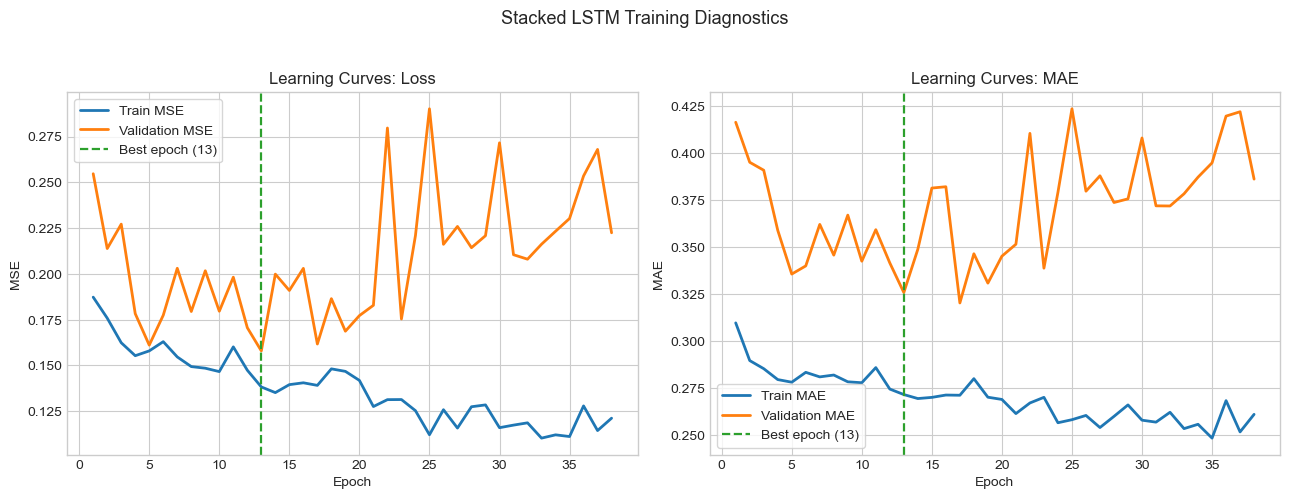

Saved: C:\Users\jijos\Desktop\261-Project\results\lstm\learning_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(history_df.index, history_df["loss"], linewidth=2.0, color="#1f77b4", label="Train MSE")
axes[0].plot(history_df.index, history_df["val_loss"], linewidth=2.0, color="#ff7f0e", label="Validation MSE")
axes[0].axvline(best_epoch, color="#2ca02c", linestyle="--", linewidth=1.6, label=f"Best epoch ({best_epoch})")
axes[0].set_title("Learning Curves: Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend(frameon=True)

axes[1].plot(history_df.index, history_df["mae"], linewidth=2.0, color="#1f77b4", label="Train MAE")
axes[1].plot(history_df.index, history_df["val_mae"], linewidth=2.0, color="#ff7f0e", label="Validation MAE")
axes[1].axvline(best_epoch, color="#2ca02c", linestyle="--", linewidth=1.6, label=f"Best epoch ({best_epoch})")
axes[1].set_title("Learning Curves: MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend(frameon=True)

fig.suptitle("Stacked LSTM Training Diagnostics", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(LEARNING_CURVE_PATH, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", LEARNING_CURVE_PATH)

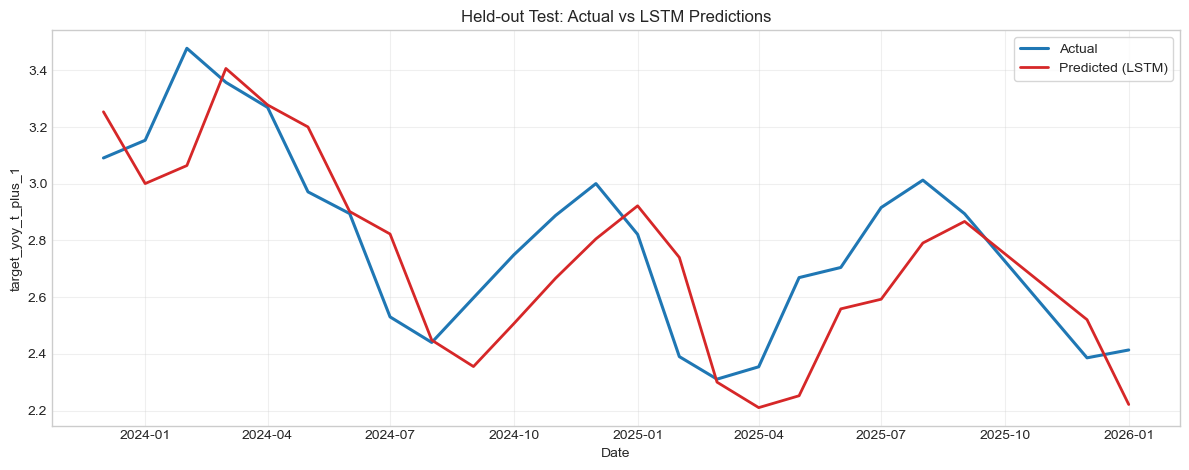

Saved: C:\Users\jijos\Desktop\261-Project\results\lstm\preds_vs_actuals.png


,actual,predicted
2023-12-01,3.090885,3.253562
2024-01-01,3.153171,3.000612
2024-02-01,3.477385,3.064084
2024-03-01,3.357364,3.406279
2024-04-01,3.269029,3.277735


In [10]:
pred_df = pd.DataFrame(
    {
        "actual": y_test,
        "predicted": y_pred_test,
    },
    index=idx_test,
).sort_index()

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(pred_df.index, pred_df["actual"], linewidth=2.2, label="Actual", color="#1f77b4")
ax.plot(pred_df.index, pred_df["predicted"], linewidth=2.0, label="Predicted (LSTM)", color="#d62728")
ax.set_title("Held-out Test: Actual vs LSTM Predictions")
ax.set_xlabel("Date")
ax.set_ylabel(TARGET_NAME)
ax.legend(frameon=True)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(PREDS_PLOT_PATH, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", PREDS_PLOT_PATH)
pred_df.head()

In [11]:
artifact_paths = {
    "model": MODEL_PATH,
    "scaler": SCALER_PATH,
    "metrics": METRICS_PATH,
    "learning_curves_plot": LEARNING_CURVE_PATH,
    "preds_vs_actuals_plot": PREDS_PLOT_PATH,
}

print("Artifact existence checks:")
for name, p in artifact_paths.items():
    print(f"- {name}: {p} | exists={p.exists()}")

all_exist = all(p.exists() for p in artifact_paths.values())
print("All required artifacts exist:", all_exist)

if not all_exist:
    raise AssertionError("One or more required artifacts were not saved.")

Artifact existence checks:
- model: C:\Users\jijos\Desktop\261-Project\models\lstm_model.keras | exists=True
- scaler: C:\Users\jijos\Desktop\261-Project\models\lstm_feature_scaler.joblib | exists=True
- metrics: C:\Users\jijos\Desktop\261-Project\results\lstm\metrics.json | exists=True
- learning_curves_plot: C:\Users\jijos\Desktop\261-Project\results\lstm\learning_curves.png | exists=True
- preds_vs_actuals_plot: C:\Users\jijos\Desktop\261-Project\results\lstm\preds_vs_actuals.png | exists=True
All required artifacts exist: True


## Lag diagnostic (timing check)
Sometimes the LSTM tracks direction but reacts late.

This check compares normal alignment vs shifted alignment (`k=-1`, `k=-2`, etc.) on validation and test.
If shifted MAE is much lower than unshifted MAE, that indicates timing lag.


In [12]:
def shift_eval(y_true, y_pred, idx, k):
    yt = pd.Series(np.asarray(y_true), index=idx)
    yp = pd.Series(np.asarray(y_pred), index=idx).shift(k)
    j = pd.concat([yt.rename("y"), yp.rename("p")], axis=1).dropna()
    return {
        "shift": int(k),
        "n": int(len(j)),
        "mae": float(np.mean(np.abs(j["y"] - j["p"]))),
        "corr": float(j["y"].corr(j["p"])),
    }

test_checks = [shift_eval(y_test, y_pred_test, pd.Index(idx_test), k) for k in range(-3, 4)]

lag_diag = {
    "target": TARGET_NAME,
    "test_window": [str(pd.Index(idx_test).min().date()), str(pd.Index(idx_test).max().date())],
    "baseline_test_mae": float(test_mae),
    "test_shift_checks": test_checks,
    "best_test_shift_by_mae": min(test_checks, key=lambda d: d["mae"]),
}

LAG_DIAG_PATH = paths["results"] / "lstm" / "lag_diagnostic.json"
LAG_DIAG_PLOT = paths["results"] / "lstm" / "lag_diagnostic_plot.png"
LAG_DIAG_PATH.write_text(json.dumps(lag_diag, indent=2), encoding="utf-8")

actual_s = pd.Series(y_test, index=pd.Index(idx_test))
pred_s = pd.Series(y_pred_test, index=pd.Index(idx_test))
pred_shift_m1 = pred_s.shift(-1)

fig, ax = plt.subplots(figsize=(12.5, 5.0))
ax.plot(actual_s.index, actual_s.values, label="Actual", linewidth=2.5, color="#1f77b4")
ax.plot(pred_s.index, pred_s.values, label="LSTM (as-is)", linewidth=2.2, color="#d62728")
ax.plot(pred_shift_m1.index, pred_shift_m1.values, label="LSTM shifted -1 (diagnostic only)", linewidth=2.0, color="#2ca02c", alpha=0.9)
ax.set_title("LSTM Lag Diagnostic on Held-out Test")
ax.set_xlabel("Date")
ax.set_ylabel(TARGET_NAME)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(LAG_DIAG_PLOT, dpi=150)
plt.close(fig)

print("Saved:", LAG_DIAG_PATH)
print("Saved:", LAG_DIAG_PLOT)
print("Best test shift by MAE:", lag_diag["best_test_shift_by_mae"])


Saved: C:\Users\jijos\Desktop\261-Project\results\lstm\lag_diagnostic.json
Saved: C:\Users\jijos\Desktop\261-Project\results\lstm\lag_diagnostic_plot.png
Best test shift by MAE: {'shift': -1, 'n': 23, 'mae': 0.10632754117250443, 'corr': 0.9830231189190404}
